In [2]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import func_plot as fp
import matplotlib.pyplot as plt
import seaborn as sns
from brainspace.gradient import GradientMaps
import func_stats as fs
import networkx as nx
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from enigmatoolbox.permutation_testing import spin_test

In [3]:
plt.rcParams["font.family"] = "Arial"

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [4]:
df = pd.read_csv('../data/df_impute.csv')
df

/var/folders/1x/vryngf3j68s4f88rfnqj0zlm0000gp/T/ipykernel_4116/1898754867.py:1: DtypeWarning: Columns (3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/df_impute.csv')


,site,ID,AO,IQ,CPZ,sans_total,site_num,DX,age,sex,...,R_rostralanteriorcingulate_thickavg,R_rostralmiddlefrontal_thickavg,R_superiorfrontal_thickavg,R_superiorparietal_thickavg,R_superiortemporal_thickavg,R_supramarginal_thickavg,R_frontalpole_thickavg,R_temporalpole_thickavg,R_transversetemporal_thickavg,R_insula_thickavg
0,01_Zurish,subj_102,31.00,NaN,150.00,41,1.0,1.0,41.0,1.0,...,2.422394,2.257372,2.412255,2.128204,2.619905,2.447482,2.500904,3.541187,2.137752,2.669681
1,01_Zurish,subj_104,16.80,NaN,150.00,13,1.0,1.0,19.0,1.0,...,2.817418,2.322853,2.667064,2.268314,2.851247,2.654902,2.634028,3.786055,2.339944,2.970092
2,01_Zurish,subj_106,25.00,NaN,150.00,44,1.0,1.0,30.0,2.0,...,2.794247,2.224263,2.597655,2.215652,2.988018,2.426096,2.113290,4.027056,2.583664,3.098219
3,01_Zurish,subj_107,29.00,NaN,300.00,9,1.0,1.0,36.0,2.0,...,3.140653,2.373414,2.802611,2.155899,2.929202,2.472076,2.767648,3.876681,2.614507,3.180831
4,01_Zurish,subj_108,22.70,NaN,333.33,27,1.0,1.0,23.0,1.0,...,2.867049,2.227360,2.668911,2.052998,2.991425,2.570095,2.570538,3.593006,2.365075,3.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9442,40_RSCZ,SCH42,23.38,NaN,NaN,NaN,40.0,1.0,24.0,2.0,...,2.630944,2.250771,2.649689,2.096278,2.641704,2.423079,2.813731,3.491770,2.419575,2.914624
9443,40_RSCZ,SCH43,26.00,NaN,NaN,NaN,40.0,1.0,26.0,2.0,...,2.809921,2.427977,2.613771,2.081858,2.655468,2.200236,2.869550,3.148980,2.070684,2.839042
9444,40_RSCZ,SCH44,23.09,NaN,NaN,NaN,40.0,1.0,23.0,2.0,...,2.908157,2.264328,2.709905,2.077051,2.662880,2.597433,2.758909,3.892109,2.364750,2.771278
9445,40_RSCZ,SCH45,21.44,NaN,NaN,NaN,40.0,1.0,22.0,2.0,...,3.147691,2.330175,2.783854,2.264509,2.810052,2.698538,2.824696,3.857079,2.521252,3.176556


In [23]:
df[df['DX']==0].DX.count()

5489

/Users/wanb/Documents/software/miniforge3/envs/general/lib/python3.10/site-packages/brainspace/plotting/surface_plotting.py:437: RuntimeWarning: Running plot_hemispheres without a display may result in a crash. For a workaround please consult https://github.com/MICA-MNI/BrainSpace/issues/66. To suppress this warning set suppress_warnings=True.
  warnings.warn(


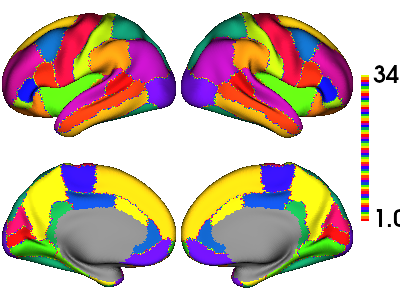

In [5]:
atlas = np.loadtxt('../src/fs_LR.dk.txt')
plot = atlas.copy()
plot[plot>34] = plot[plot>34] - 34
plot[atlas==0]=np.nan
fp.plot_surface(data=plot, size=(400,300), cmap='prism', layout_style = 'grid',
                display=True, filename='../figures/dk_atlas.png')

In [6]:
df_panss = pd.read_csv('../data/data_PANSS.csv')
df_panss = df_panss.dropna().reset_index(drop=True)
panss = [1,3,1,5,1,1,5,
         2,2,2,2,3,2,3,
         6,4,4,5,3,4,2,5,1,3,3,1,2,5,6,2]
label = ['Positive', 'Negative', 'Disorganization', 'Depression/anxiety', 'Hostility', 'Non-categorized']
for i in range(5):
  df_panss['c'+str(i+1)] = np.array(df_panss[df_panss.columns[2:32]])[:,np.array(panss)==i+1].sum(axis=1)
df_panss

,site,ID,PANSS1,PANSS2,PANSS3,PANSS4,PANSS5,PANSS6,PANSS7,PANSS8,...,PANSS26,PANSS27,PANSS28,PANSS29,PANSS30,c1,c2,c3,c4,c5
0,01_Zurish,subj_102,4.0,1,4,1,1,1,1.0,2,...,1,1,1,1,2,15.0,17.0,6.0,3.0,5.0
1,01_Zurish,subj_104,1.0,1,1,2,1,2,1.0,1,...,1,1,1,1,3,7.0,13.0,7.0,6.0,6.0
2,01_Zurish,subj_106,3.0,3,3,2,1,3,2.0,5,...,1,1,4,1,5,14.0,25.0,12.0,3.0,10.0
3,01_Zurish,subj_107,2.0,1,1,1,2,2,1.0,1,...,3,1,1,1,2,12.0,12.0,6.0,3.0,5.0
4,01_Zurish,subj_108,1.0,1,1,1,1,1,1.0,3,...,1,1,1,1,3,6.0,14.0,6.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,40_RSCZ,SCH42,2.0,2,1,1,1,2,1.0,3,...,4,1,1,2,3,13.0,19.0,14.0,7.0,6.0
1079,40_RSCZ,SCH43,2.0,2,1,1,1,1,1.0,3,...,2,2,1,1,1,8.0,17.0,13.0,5.0,6.0
1080,40_RSCZ,SCH44,1.0,2,1,1,1,1,1.0,2,...,1,1,1,2,1,6.0,11.0,10.0,6.0,5.0
1081,40_RSCZ,SCH45,3.0,3,3,1,1,2,1.0,3,...,4,3,1,3,3,16.0,27.0,16.0,3.0,6.0


In [7]:
demo = pd.DataFrame()
demo['site'] = np.unique(df.site)
demo['n SCZ'] = [np.logical_and(df.site == i, df.DX==1).sum() for i in np.unique(df.site)]
demo['n CTR'] = [np.logical_and(df.site == i, df.DX==0).sum() for i in np.unique(df.site)]
demo['n Female'] = [np.logical_and(df.site == i, df.sex==2).sum() for i in np.unique(df.site)]
demo['n Male'] = [np.logical_and(df.site == i, df.sex==1).sum() for i in np.unique(df.site)]
demo['Age mean'] = [df[df.site==i].age.mean().round(1) for i in np.unique(df.site)]
demo['Age std'] = [df[df.site==i].age.std().round(1) for i in np.unique(df.site)]
demo['Age min'] = [df[df.site==i].age.min().astype(int) for i in np.unique(df.site)]
demo['Age max'] = [df[df.site==i].age.max().astype(int) for i in np.unique(df.site)]
demo['CT mean'] = [np.array(df[df.site==i][fp.region_list]).mean(axis=None).round(2) for i in np.unique(df.site)]
demo['CT std'] = [np.array(df[df.site==i][fp.region_list]).std(axis=None).round(2) for i in np.unique(df.site)]
demo['ICV mean'] = [df[df.site==i].ICV.mean().astype(int) for i in np.unique(df.site)]
for j in range(5):
    panss_mean=[]
    panss_std=[]
    for i in np.unique(df.site):
        try:
            panss_mean.append(df_panss[df_panss.site==i]['c'+str(j+1)].mean().round(1))
            panss_std.append(df_panss[df_panss.site==i]['c'+str(j+1)].std().round(1))
        except:
            panss_mean.append(np.nan)
            panss_std.append(np.nan)
    demo['PANSS '+ label[j] + ' mean'] = panss_mean
    demo['PANSS '+ label[j] + ' std'] = panss_std
demo.to_csv('../results/Demographics.csv', index=None)
demo

,site,n SCZ,n CTR,n Female,n Male,Age mean,Age std,Age min,Age max,CT mean,...,PANSS Positive mean,PANSS Positive std,PANSS Negative mean,PANSS Negative std,PANSS Disorganization mean,PANSS Disorganization std,PANSS Depression/anxiety mean,PANSS Depression/anxiety std,PANSS Hostility mean,PANSS Hostility std
0,01_Zurish,60,28,25,63,31.2,8.7,18,55,2.53,...,9.8,2.9,16.5,6.5,8.2,2.3,5.5,2.4,6.2,1.6
1,02_HUBIN,113,113,69,157,41.6,8.3,19,56,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,03_NU,107,92,75,124,33.0,13.7,14,68,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,04_PAFIP,352,195,213,334,29.6,8.4,15,58,2.53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05_ROMA,157,115,96,176,38.6,11.5,16,70,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,06_Voice_CAGEMIS,40,48,48,40,37.1,12.8,18,66,2.55,...,17.8,7.6,15.3,5.9,11.6,3.4,9.1,4.4,7.6,2.4
6,07_Galway,64,231,130,165,37.8,12.6,18,65,2.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,08_ASRB,55,40,46,49,40.6,12.0,18,62,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,09_CAMH,118,146,117,147,43.8,17.9,18,86,2.54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10_CIAM,16,30,21,25,28.2,6.1,19,40,2.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
demo['n SCZ'].sum()

3958

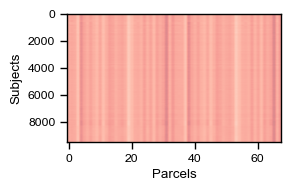

In [7]:
sns.set_context("paper", font_scale = 1)
fig, ax = plt.subplots(figsize=(3,2))
ax.imshow(df[fp.region_list],aspect='auto', cmap='Reds', alpha=0.5)
ax.set_xlabel('Parcels')
ax.set_ylabel('Subjects')
fig.tight_layout()
fig.savefig('../figures/whole_sample_ct.png', transparent=True, dpi=300)

## Whole sample comparisons

In [8]:
# regress out age and sex
data_combat = np.array(df[fp.region_list])
data_combat_regress = np.zeros(data_combat.shape)
for i in range(68):
  model = OLS(data_combat[:,i], add_constant(df[['age','sex']])).fit()
  data_combat_regress[:,i] = data_combat[:,i] - model.predict(add_constant(df[['age','sex']]))

In [9]:
spa = 80 # top 100 - spa
data_scz = data_combat_regress[df.DX == 1]
data_ctr = data_combat_regress[df.DX == 0]
cova_scz = np.corrcoef(data_scz.T)
cova_ctr = np.corrcoef(data_ctr.T)
cova_scz_spa = cova_scz.copy()
cova_ctr_spa = cova_ctr.copy()
for i in range(68):
  cova_scz_spa[i][cova_scz_spa[i]<np.percentile(cova_scz_spa[i], spa)]=0
  cova_ctr_spa[i][cova_ctr_spa[i]<np.percentile(cova_ctr_spa[i], spa)]=0
data_ctr.shape, data_scz.shape

((5489, 68), (3958, 68))

In [10]:
data_scz = data_combat_regress[df.DX == 1]
data_ctr = data_combat_regress[df.DX == 0]
cova_scz = np.corrcoef(data_scz.T)
cova_ctr = np.corrcoef(data_ctr.T)

for spa in range(60,91):
  cova_scz_spa = cova_scz.copy()
  cova_ctr_spa = cova_ctr.copy()
  for i in range(68):
    cova_scz_spa[i][cova_scz_spa[i]<np.percentile(cova_scz_spa[i], spa)]=0
    cova_ctr_spa[i][cova_ctr_spa[i]<np.percentile(cova_ctr_spa[i], spa)]=0

  G_scz = nx.from_numpy_array(cova_scz_spa)
  G_ctr = nx.from_numpy_array(cova_ctr_spa)
  sw_scz = fs.regional_small_worldness(G_scz)
  sw_ctr = fs.regional_small_worldness(G_ctr)

  cluster_ctr = np.array(list(sw_ctr[0].values()))
  length_ctr = np.array(list(sw_ctr[1].values()))
  cluster_scz = np.array(list(sw_scz[0].values()))
  length_scz = np.array(list(sw_scz[1].values()))

  length_scz = (length_scz - length_scz.min())/(length_scz.max() - length_scz.min())
  length_ctr = (length_ctr - length_ctr.min())/(length_ctr.max() - length_ctr.min())
  cluster_scz = (cluster_scz - cluster_scz.min())/(cluster_scz.max() - cluster_scz.min())
  cluster_ctr = (cluster_ctr - cluster_ctr.min())/(cluster_ctr.max() - cluster_ctr.min())

  gm_ctr = GradientMaps(approach='dm', kernel='normalized_angle')
  gm_ctr.fit(cova_ctr_spa, sparsity=0)
  gm_scz = GradientMaps(approach='dm', kernel='normalized_angle', alignment='procrustes')
  gm_scz.fit(cova_scz_spa, sparsity=0, reference=gm_ctr.gradients_)
  np.savetxt('../data/gm_ctr'+str(spa)+'.txt', gm_ctr.gradients_)
  np.savetxt('../data/gm_scz'+str(spa)+'.txt', gm_scz.gradients_)
  np.savetxt('../data/gm_scz_aligned'+str(spa)+'.txt', gm_scz.aligned_)

  np.savetxt('../data/length_scz'+str(spa)+'.txt', length_scz)
  np.savetxt('../data/length_ctr'+str(spa)+'.txt', length_ctr)
  np.savetxt('../data/cluster_scz'+str(spa)+'.txt', cluster_scz)
  np.savetxt('../data/cluster_ctr'+str(spa)+'.txt', cluster_ctr)

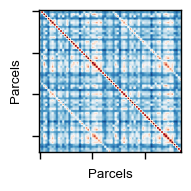

In [11]:
#sns.set_context("paper", font_scale = 3)
fig, ax = plt.subplots(figsize=(2,2))
ax.imshow(cova_ctr,aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Parcels')
ax.set_ylabel('Parcels')
ax.set_xticklabels([])
ax.set_yticklabels([])
fig.tight_layout()
fig.savefig('../figures/whole_sample_cova_ctr'+str(spa)+'.png', transparent=True, dpi=300)

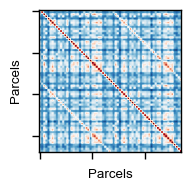

In [12]:
fig, ax = plt.subplots(figsize=(2,2))
ax.imshow(cova_scz,aspect='auto', cmap='RdBu_r')
ax.set_xlabel('Parcels')
ax.set_ylabel('Parcels')
ax.set_xticklabels([])
ax.set_yticklabels([])
fig.tight_layout()
fig.savefig('../figures/whole_sample_cova_scz'+str(spa)+'.png', transparent=True, dpi=300)

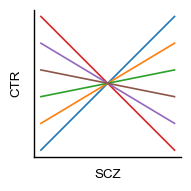

In [13]:
fig, ax = plt.subplots(figsize=(2,2))
ax.plot([0,1],[0,1])
ax.plot([0,1],[0.2,0.8])
ax.plot([0,1],[0.4,0.6])
ax.plot([1,0],[0,1])
ax.plot([1,0],[0.2,0.8])
ax.plot([1,0],[0.4,0.6])
ax.set_xlabel('SCZ')
ax.set_ylabel('CTR')
ax.set_xticks([])
ax.set_yticks([])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/a_group_level_selection.png', transparent=True, dpi=300)

In [14]:
spa = np.arange(60,91)
cluster_ctr = [None] * len(spa)
cluster_scz = [None] * len(spa)
length_ctr = [None] * len(spa)
length_scz = [None] * len(spa)
g1_ctr = [None] * len(spa)
g1_scz = [None] * len(spa)
g2_ctr = [None] * len(spa)
g2_scz = [None] * len(spa)
for i in range(len(spa)):
  g1_ctr[i] = np.loadtxt('../data/gm_ctr'+str(spa[i])+'.txt')[:,0]
  g1_scz[i] = np.loadtxt('../data/gm_scz'+str(spa[i])+'.txt')[:,0]
  g2_ctr[i] = np.loadtxt('../data/gm_ctr'+str(spa[i])+'.txt')[:,1]
  g2_scz[i] = np.loadtxt('../data/gm_scz'+str(spa[i])+'.txt')[:,1]
  cluster_ctr[i] = np.loadtxt('../data/cluster_ctr'+str(spa[i])+'.txt')
  cluster_scz[i] = np.loadtxt('../data/cluster_scz'+str(spa[i])+'.txt')
  length_ctr[i] = np.loadtxt('../data/length_ctr'+str(spa[i])+'.txt')
  length_scz[i] = np.loadtxt('../data/length_scz'+str(spa[i])+'.txt')

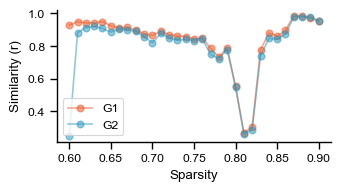

In [15]:
fig, ax = plt.subplots(figsize=(3.5,2))

ax.plot(np.arange(60,91)/100,[abs(ss.pearsonr(g1_ctr[i],g1_scz[i])[0]) for i in range(31)],
        label = 'G1', color=fp.red, marker='o', alpha=0.5)
ax.plot(np.arange(60,91)/100,[abs(ss.pearsonr(g2_ctr[i],g2_scz[i])[0]) for i in range(31)], 
        label = 'G2', color=fp.blue, marker='o', alpha=0.5)
ax.set_ylabel('Similarity (r)')
ax.set_xlabel('Sparsity')
#ax.set_xticks(range(7))
#ax.set_xticklabels(['0.90','0.85','0.80','0.75','0.70','0.65','0.60'])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(loc="lower left")

fig.tight_layout()
fig.savefig('../figures/whole_sample_gm_similarity.png', transparent=True, dpi=300)

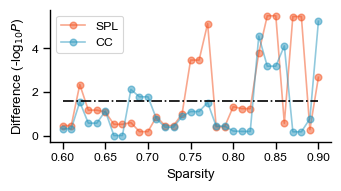

In [16]:
fig, ax = plt.subplots(figsize=(3.5,2))

c = [-np.log10(ss.ttest_rel(cluster_ctr[i],cluster_scz[i])[1]) for i in range(31)]
l = [-np.log10(ss.ttest_rel(length_ctr[i],length_scz[i])[1]) for i in range(31)]

ax.plot(np.arange(60,91)/100,l, 
        label = 'SPL', color=fp.red, marker='o', alpha=0.5)
ax.plot(np.arange(60,91)/100,c, 
        label = 'CC', color=fp.blue, marker='o', alpha=0.5)
ax.set_ylabel('Difference (-log$_{10}$$\it{P}$)')
ax.set_xlabel('Sparsity')
#ax.set_xticks(range(7))
#ax.set_xticklabels(['0.90','0.85','0.80','0.75','0.70','0.65','0.60'])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.hlines(y=-np.log10(0.05/2), xmin=0.6,xmax=0.9, color='black',ls='-.')
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig('../figures/whole_sample_topology_similarity.png', transparent=True, dpi=300)

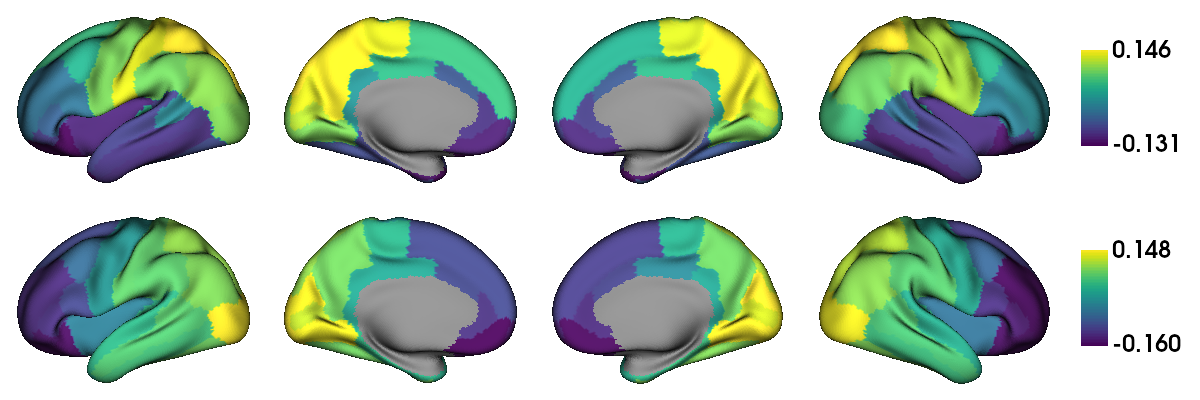

In [40]:
spa=80
tmp = [g1_ctr[spa-60], g1_scz[spa-60]]
if ss.pearsonr(tmp[0],tmp[1])[0] < 0:
  tmp[1] = -tmp[1]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='viridis',
                display=True, filename='../figures/whole_sample_g1_'+str(spa)+'.png') 

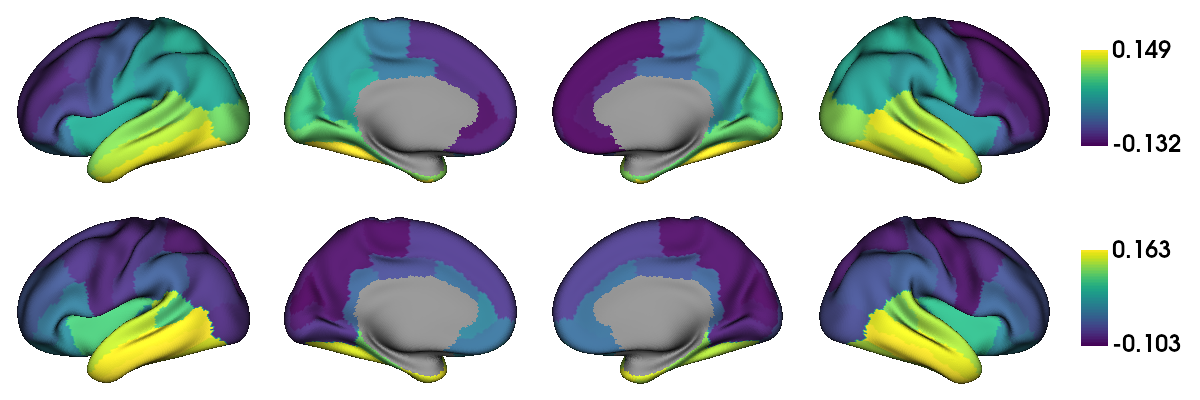

In [41]:
tmp = [g2_ctr[spa-60], g2_scz[spa-60]]
if ss.pearsonr(tmp[0],tmp[1])[0] < 0:
  tmp[1] = -tmp[1]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='viridis',
                display=True, filename='../figures/whole_sample_g2_'+str(spa)+'.png')

[20.66863127 17.2036684 ]
[21.54855598 17.09912745]


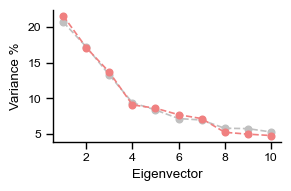

In [19]:
fig, ax = plt.subplots(figsize=(3,2))

ax.plot(range(1,11), gm_ctr.lambdas_*100/gm_ctr.lambdas_.sum(), color='silver', marker='o', ls='--')
ax.plot(range(1,11), gm_scz.lambdas_*100/gm_scz.lambdas_.sum(), color='lightcoral', marker='o', ls='--')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Variance %')
ax.set_xlabel('Eigenvector')

fig.tight_layout()
fig.savefig('../figures/whole_sample_gradientlambda'+str(spa)+'.png', transparent=True, dpi=300)
print(gm_ctr.lambdas_[:2]*100/gm_ctr.lambdas_.sum())
print(gm_scz.lambdas_[:2]*100/gm_scz.lambdas_.sum())

In [20]:
print(ss.pearsonr(gm_ctr.gradients_[:,0],-gm_scz.gradients_[:,0]))
print(spin_test(gm_ctr.gradients_[:,0],-gm_scz.gradients_[:,0], surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

PearsonRResult(statistic=-0.9514672726184566, pvalue=1.7081679292362454e-35)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([ 0.34122933, -0.64212709,  0.42520952, ..., -0.31899506,
       -0.1494099 , -0.00294918]))


In [21]:
print(ss.pearsonr(gm_ctr.gradients_[:,1],gm_scz.gradients_[:,1]))
print(spin_test(gm_ctr.gradients_[:,1],-gm_scz.gradients_[:,1], surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

PearsonRResult(statistic=0.9542329225093316, pvalue=2.574644433627009e-36)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([ 0.0167323 , -0.31640565, -0.26619305, ..., -0.67036363,
       -0.21199468,  0.05105759]))


PearsonRResult(statistic=-0.9514672726184566, pvalue=1.7081679292362454e-35)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([ 0.58641938,  0.27275081,  0.09891956, ..., -0.0333642 ,
       -0.07923323,  0.3284058 ]))


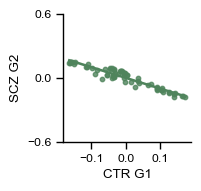

In [22]:
fig, ax = plt.subplots(figsize=(2.1,2))

sns.regplot(x=gm_ctr.gradients_[:,0],y=-gm_scz.gradients_[:,0], ax=ax,
            color='#4F845C', scatter_kws={'s':10})

print(ss.pearsonr(gm_ctr.gradients_[:,0],-gm_scz.gradients_[:,0]))
print(spin_test(gm_ctr.gradients_[:,0],-gm_scz.gradients_[:,0], surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([-0.6,0,0.6])
ax.set_xlabel('CTR G1')
ax.set_ylabel('SCZ G2')

fig.tight_layout()
fig.savefig('../figures/whole_sample_gradcorr1_'+str(spa)+'.png', transparent=True, dpi=300)

In [23]:
import func_corrstats as fc

In [24]:
fc.dependent_corr(ss.pearsonr(gm_ctr.gradients_[:,0],-gm_scz.gradients_[:,1])[0], 
                  ss.pearsonr(gm_ctr.gradients_[:,0], gm_ctr.gradients_[:,1])[0],
                  ss.pearsonr(gm_ctr.gradients_[:,1],-gm_scz.gradients_[:,1])[0], 
                  68, twotailed=True, conf_level=0.95, method='steiger')

(-1.038260550422696, 0.3029376610387253)

PearsonRResult(statistic=0.9542329225093316, pvalue=2.574644433627009e-36)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([-0.56025852, -0.45102665,  0.40858879, ..., -0.05884035,
        0.27785569,  0.22347532]))


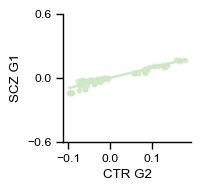

In [25]:
fig, ax = plt.subplots(figsize=(2.1,2))

sns.regplot(x=gm_ctr.gradients_[:,1],y=gm_scz.gradients_[:,1], ax=ax,
            color='#CFE7C4', scatter_kws={'s':10})

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_yticks([-0.6,0,0.6])
ax.set_xlabel('CTR G2')
ax.set_ylabel('SCZ G1')

print(ss.pearsonr(gm_ctr.gradients_[:,1],gm_scz.gradients_[:,1]))
print(spin_test(gm_ctr.gradients_[:,1],gm_scz.gradients_[:,1], surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

fig.tight_layout()
fig.savefig('../figures/whole_sample_gradcorr2_'+str(spa)+'.png', transparent=True, dpi=300)

In [26]:
fc.dependent_corr(ss.pearsonr(gm_ctr.gradients_[:,1],-gm_scz.gradients_[:,0])[0], 
                  ss.pearsonr(gm_ctr.gradients_[:,0], gm_ctr.gradients_[:,1])[0],
                  ss.pearsonr(gm_ctr.gradients_[:,1],-gm_scz.gradients_[:,1])[0], 
                  68, twotailed=True, conf_level=0.95, method='steiger')

(1.1036365348473505, 0.27375853025754404)

In [48]:
spa=90
cluster_ctr = np.loadtxt('../data/cluster_ctr'+str(spa)+'.txt')
cluster_scz = np.loadtxt('../data/cluster_scz'+str(spa)+'.txt')
length_ctr = np.loadtxt('../data/length_ctr'+str(spa)+'.txt')
length_scz = np.loadtxt('../data/length_scz'+str(spa)+'.txt')

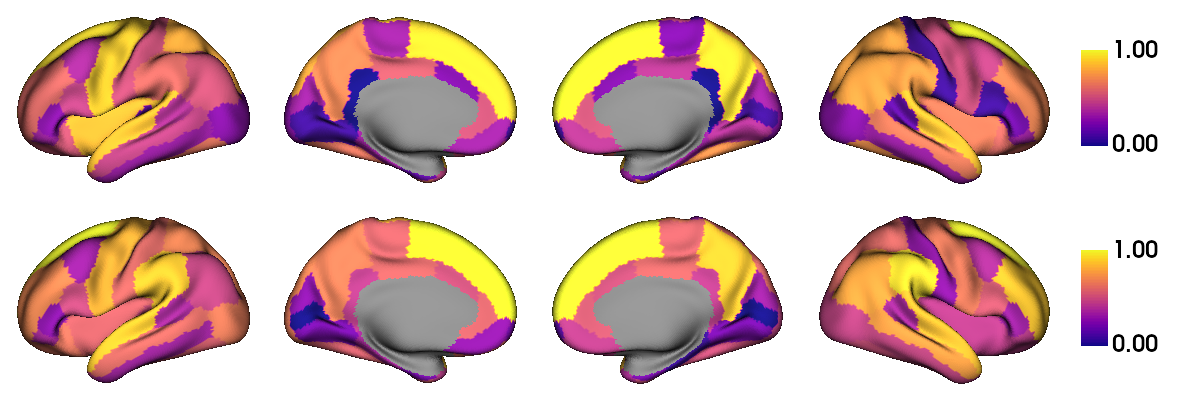

In [49]:
tmp = [length_ctr, length_scz]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='plasma', #color_range=(0,1),
                display=True, filename='../figures/whole_sample_SPL_'+str(spa)+'.png')

In [29]:
print(ss.pearsonr(length_ctr, length_scz))
print(spin_test(length_ctr, length_scz, surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

PearsonRResult(statistic=0.9168359373610446, pvalue=5.131087857374738e-28)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([-0.08244955, -0.10405285,  0.05641325, ..., -0.07153631,
        0.12647816,  0.01543689]))


TtestResult(statistic=0.9666252686112441, pvalue=0.33720769444848275, df=67)


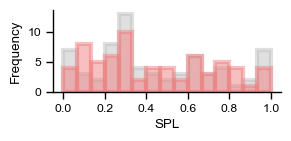

In [30]:
fig, ax = plt.subplots(figsize=(3,1.5))

ax.hist(length_ctr, bins=15, ls='-', lw=3, facecolor='silver', edgecolor='silver', alpha=0.5)
ax.hist(length_scz, bins=15, ls='-', lw=3, facecolor='lightcoral', edgecolor='lightcoral', alpha=0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylabel('Frequency')
ax.set_xlabel('SPL')
fig.tight_layout()
fig.savefig('../figures/whole_sample_SPL_fre'+str(spa)+'.png', transparent=True, dpi=300)

print(ss.ttest_rel(length_ctr,length_scz))

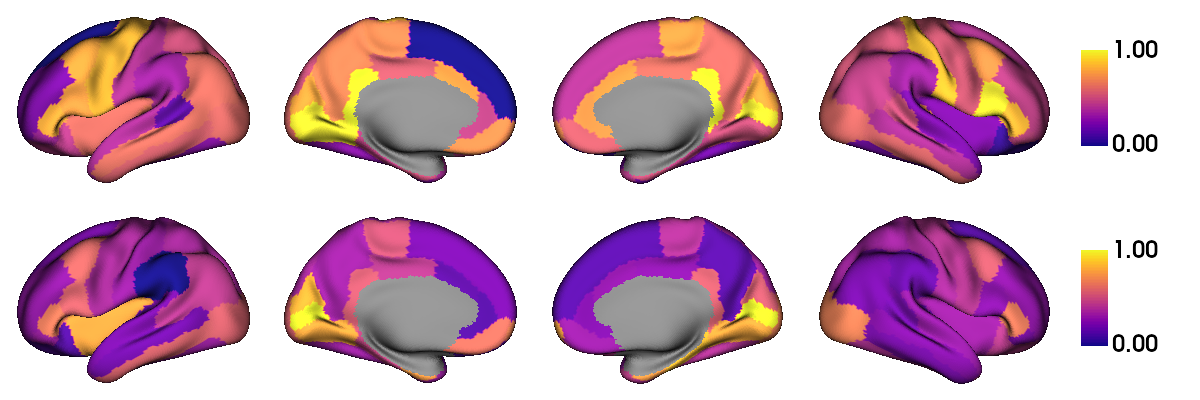

In [50]:
tmp = [cluster_ctr, cluster_scz]
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(1200,200*len(tmp)), cmap='plasma', #color_range=(0,1),
                display=True, filename='../figures/whole_sample_CC_'+str(spa)+'.png')

In [32]:
print(ss.pearsonr(cluster_ctr, cluster_scz))
print(spin_test(cluster_ctr, cluster_scz, surface_name='fsa5', parcellation_name='aparc',
          type='pearson', n_rot=1000, null_dist=True))

PearsonRResult(statistic=0.9011141044951985, pvalue=1.2049812847777695e-25)
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
(0.0, array([ 0.03657079, -0.14823363,  0.03663125, ...,  0.09800102,
        0.10163382, -0.02396356]))


TtestResult(statistic=-0.7286037635534997, pvalue=0.46878317898920485, df=67)


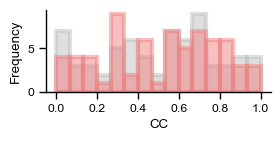

In [33]:
fig, ax = plt.subplots(figsize=(3,1.5))

ax.hist(cluster_ctr, bins=15, ls='-', lw=3, facecolor='silver', edgecolor='silver', alpha=0.5)
ax.hist(cluster_scz, bins=15, ls='-', lw=3, facecolor='lightcoral', edgecolor='lightcoral', alpha=0.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_ylabel('Frequency')
ax.set_xlabel('CC')
fig.tight_layout()
fig.savefig('../figures/whole_sample_CC_fre'+str(spa)+'.png', transparent=True, dpi=300)

print(ss.ttest_rel(cluster_ctr,cluster_scz))